In [15]:
# !pip install -e ../../Xaurora-dev
%load_ext autoreload
%autoreload 2
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import os
from xaurora_configs import (
    deterministic_prediction_configs,
    probabilistic_prediction_configs,
    target_configs,
)
from xaurora.constants._aurora import AuroraVariables
from xaurora.data.utils._xarray import open_zarr_over_ssh

SURFACE_VARIABLES = ['2m_temperature', 'mean_sea_level_pressure', '10m_u_component_of_wind', '10m_v_component_of_wind']
ATMOSPHERIC_VARIABLES = ['temperature', 'geopotential', 'u_component_of_wind', 'v_component_of_wind', 'specific_humidity']
SHORT_NAME_MAP = AuroraVariables.GCS_MAP.value
UNIT_MAP = AuroraVariables.UNITS.value
SQUARED_UNIT_MAPS = AuroraVariables.SQUARED_UNITS.value

wb_prediction_configs = {
    # GENCAST MODELS FOR 2022 CANNOT BE FOUND ON BENCHMARK_RESULTS (GS). 
    # I DON'T TRUST MY SCRAP AS THE AURORA ONE WAS OFF. WE WILL USE FGN INSTEAD.
    # # GenCast operational 2022
    # "gencast_hres_init_vs_era5_2022": {
    #     "forecast_path": None,
    #     "metrics_path": "/Users/eliotwalt/Documents/phd/code/weatherbenchX/scraping/scores/gencast_hres_init_vs_era5_1440x721_2022.nc",
    #     "name": "GenCast (Oper.) vs ERA5 2022",
    #     "probabilistic": True
    # },
    # "gencast_hres_init_vs_hres_t0_2022": {
    #     "forecast_path": None,
    #     "metrics_path": "/Users/eliotwalt/Documents/phd/code/weatherbenchX/scraping/scores/gencast_hres_init_vs_hres_t0_1440x721_2022.nc",
    #     "name": "GenCast (Oper.) vs HRES T0 2022",
    #     "probabilistic": True
    # },
    
    # ===================== DETERMINISTIC MODELS =====================
    # Graphcast operational 2022
    "graphcast_hres_init_vs_hres_t0_1440x721_2022": {
        "forecast_path": None,
        "metrics_path": "https://storage.googleapis.com/weatherbench2/benchmark_results/graphcast_hres_init_vs_hres_t0_1440x721_2022.nc",
        "name": "GraphCast (Oper.) vs HRES T0 2022",
        "probabilistic": False
    },
    # Aurora operational
    "aurora_hres_init_vs_hres_t0_2022": {
        "forecast_path": None,
        "metrics_path": "https://storage.googleapis.com/weatherbench2/benchmark_results/aurora_vs_hres_t0_1440x721_2022.nc",
        "name": "Aurora (Oper.) vs HRES T0 2022",
        "probabilistic": False
    },
    "aurora_vs_era5_2022": {
        "forecast_path": None,
        "metrics_path": "https://storage.googleapis.com/weatherbench2/benchmark_results/aurora_vs_era5_1440x721_2022.nc",
        "name": "Aurora (Oper.) vs ERA5 2022",
        "probabilistic": False
    },
    # HRES T0 2022 
    "hres_vs_hres_t0_1440x721_2022": {
        "forecast_path": None,
        "metrics_path": "https://storage.googleapis.com/weatherbench2/benchmark_results/hres_vs_hres_t0_1440x721_2022.nc",
        "name": "HRES T0 2022",
        "probabilistic": False
    },
    # ===================== PROBABILISTIC MODELS =====================
    # FGN operational 2022
    "fgn_operational_vs_hres_t0_1440x721_2022.nc": {
        "forecast_path": None,
        "metrics_path": "https://storage.googleapis.com/weatherbench2/benchmark_results/fgn_operational_vs_hres_t0_1440x721_2022.nc",
        "name": "FGN (Oper.) vs HRES T0 2022",
        "probabilistic": True
    },
    # IFS ENS operational
    "ens_vs_hres_t0_1440x721_2022.nc": {
        "forecast_path": None,
        "metrics_path": "https://storage.googleapis.com/weatherbench2/benchmark_results/ens_vs_hres_t0_1440x721_2022.nc",
        "name": "IFS ENS vs HRES T0 2022",
        "probabilistic": True
    },    
}

CONFIG = {}
CONFIG.update(probabilistic_prediction_configs)
CONFIG.update(deterministic_prediction_configs)
CONFIG.update(wb_prediction_configs)
CONFIG.keys()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


dict_keys(['ens_1440x721_2021', 'ens_1440x721_2022', 'xaurora_small_1440x721_2021', 'xaurora_small_fm_1440x721_2021', 'xaurora_1440x721_2021', 'xaurora_1440x721_2022', 'xaurora_zero_shot_hres_init_1440x721_2022', 'xaurora_finetuned_hres_init_1440x721_2022', 'era5_1440x721_2021', 'era5_1440x721_2022', 'hres_1440x721_2021', 'hres_1440x721_2022', 'hres_64x32_2021', 'hres_64x32_2022', 'ens_mean_1440x721_2021', 'ens_mean_1440x721_2022', 'aurora_small_pretrained_1440x721_2021', 'aurora_pretrained_1440x721_2021', 'aurora_pretrained_1440x721_2022', 'aurora_finetuned_no_lora_hres_init_1440x721_2022', 'aurora_finetuned_hres_init_1440x721_2022', 'aurora_finetuned_from_aurora_hres_init_1440x721_2022', 'ens_single_member_1440x721_2021', 'ens_single_member_1440x721_2022', 'graphcast_hres_init_vs_hres_t0_1440x721_2022', 'aurora_hres_init_vs_hres_t0_2022', 'aurora_vs_era5_2022', 'hres_vs_hres_t0_1440x721_2022', 'fgn_operational_vs_hres_t0_1440x721_2022.nc', 'ens_vs_hres_t0_1440x721_2022.nc'])

In [ ]:
def load_anything(path):
    !mkdir -p ../bechmark_results/
    
    # build local path
    if path.startswith("https://"):
        local_path = f'../bechmark_results/https-gs-wb2_{os.path.basename(path)}'
    else:
        local_path = f'../bechmark_results/{os.path.basename(path)}'
    
    # 1. https -> CURL
    if path.startswith("https://"):
        print(f"Downloading {path} to {local_path}")
        !curl -L -o {local_path} {path}
        return xr.open_dataset(local_path)
        
    # 2. a path that cannot be accessed directly but can be scp'ed from snellius1
    elif not os.path.exists(local_path):
        print(f"Copying snellius1:{path} to {local_path}")
        !scp -r snellius1:{path} {local_path}
        
    return xr.open_dataset(local_path)

def adapt_datasets(datasets):
    for i, ds in enumerate(datasets):
        if np.all(ds.region.values == "Global"):
            datasets[i] = ds.copy()
            datasets[i]["region"] = ["global"]
        for dv in ds.data_vars:
            new_dv = dv
            if "sea_level_pressure" in new_dv:
                new_dv = new_dv.replace(".sea_level_pressure", ".mean_sea_level_pressure")
            if 'spreadskill' in new_dv:
                new_dv = new_dv.replace("spreadskill", "spread_skill")
            datasets[i] = datasets[i].rename({dv: new_dv})
    return datasets

def get_metric_path(key):
    if 'metrics_path' in CONFIG[key]:
        return CONFIG[key]['metrics_path']
    else:
        if 'path' in CONFIG[key]:
            metrics_path = os.path.join(os.path.dirname(CONFIG[key]['path']), f'{key}.nc')
            return metrics_path
    raise ValueError(f"No path found for key {key}")

def plot_metric(metrics, datasets, labels, which_variables, sel_kwargs, logy=False, unitless=False, title=None):
    if which_variables == "surface":
        variables = SURFACE_VARIABLES
    elif which_variables == "atmospheric":
        variables = ATMOSPHERIC_VARIABLES
    
    datasets = [ds.sel(**sel_kwargs, drop=True) for ds in datasets]
    
    def calculate_levels(datasets):
        if which_variables == 'surface': return [None]
        levels = datasets[0].level.values
        for ds in datasets[1:]:
            _levels = ds.level.values
            # remove levels that are not in all datasets
            levels = np.intersect1d(levels, _levels)
        return levels
        
    
    nvars = len(variables)
    levels = calculate_levels(datasets)
    nlevels = len(levels) if which_variables == "atmospheric" else 1
    
    fig, axs = plt.subplots(ncols=nvars, nrows=nlevels, figsize=(4*nvars, 3*nlevels))
    if nlevels == 1:
        axs = np.expand_dims(axs, axis=0)
        sel_level_fn = lambda ds, j: ds
    else:
        sel_level_fn = lambda ds, j: ds.sel(level=levels[j])
    
    for i, var in enumerate(variables):
        svar = SHORT_NAME_MAP[var]
        for j in range(nlevels):
            varname = svar if which_variables == "surface" else f"{svar}{levels[j]}"
            for ds, metric, label in zip(datasets, metrics, labels):
                lead_times = ds["lead_time"].values.astype("timedelta64[h]").astype(int)
                axs[j,i].plot(lead_times, sel_level_fn(ds, j)[f"{metric}.{var}"], label=label)
            axs[j,i].set_xlabel("Lead time (hours)")
            if logy:
                axs[j,i].set_yscale("log")
            if j == 0: 
                axs[j,i].set_title('')
            if unitless:
                axs[j,i].set_ylabel(f"{varname}")
            else:
                axs[j,i].set_ylabel(f"{varname} [{UNIT_MAP[svar]}]")
    
    if title is not None:
        fig.suptitle(title)
    else:
        metric_name = [part.capitalize() for part in metrics[-1].split("_")]
        metric_name[-1] = metric_name[-1].upper()
        fig.suptitle(" ".join(metric_name))
                
    offset = -0.18 if which_variables == 'surface' else -0.07
    handles, labels = axs[0,0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, offset), ncol=4)
    
    
    plt.tight_layout()
    plt.show()    

## Aurora reproducibility

In [4]:
for key in CONFIG.keys():
    if "aurora" in key:
        print(key)

xaurora_small_1440x721_2021
xaurora_small_fm_1440x721_2021
xaurora_1440x721_2021
xaurora_1440x721_2022
xaurora_zero_shot_hres_init_1440x721_2022
xaurora_finetuned_hres_init_1440x721_2022
aurora_small_pretrained_1440x721_2021
aurora_pretrained_1440x721_2021
aurora_pretrained_1440x721_2022
aurora_finetuned_no_lora_hres_init_1440x721_2022
aurora_finetuned_hres_init_1440x721_2022
aurora_finetuned_from_aurora_hres_init_1440x721_2022
aurora_hres_init_vs_hres_t0_2022


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1271k  100 1271k    0     0  8730k      0 --:--:-- --:--:-- --:--:-- 8766k


/var/folders/l9/513m2x1n1xj1ss41yczgxvmr0000gn/T/ipykernel_4887/1833877850.py:14: FutureWarning: In a future version, xarray will not decode the variable 'lead_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  return xr.open_dataset(local_path)


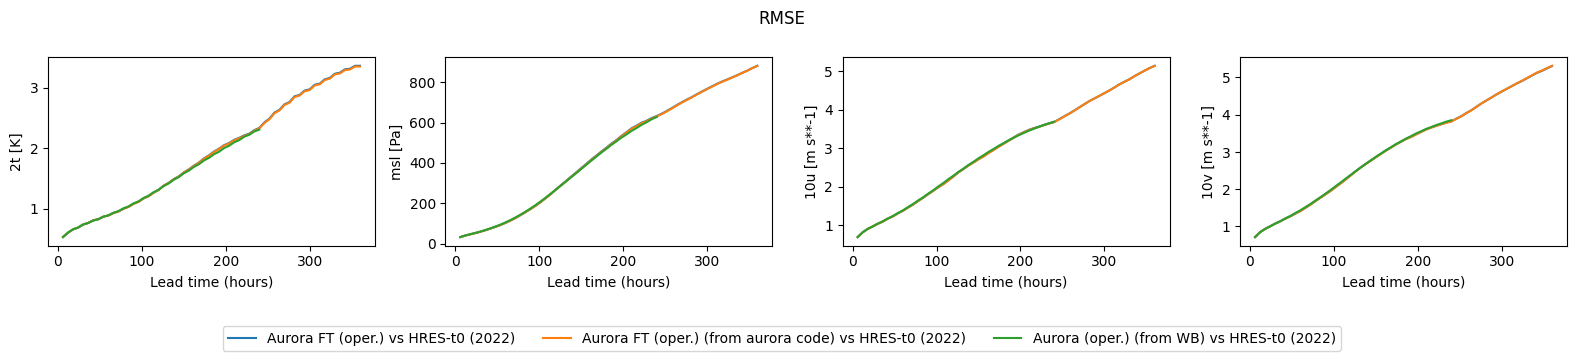

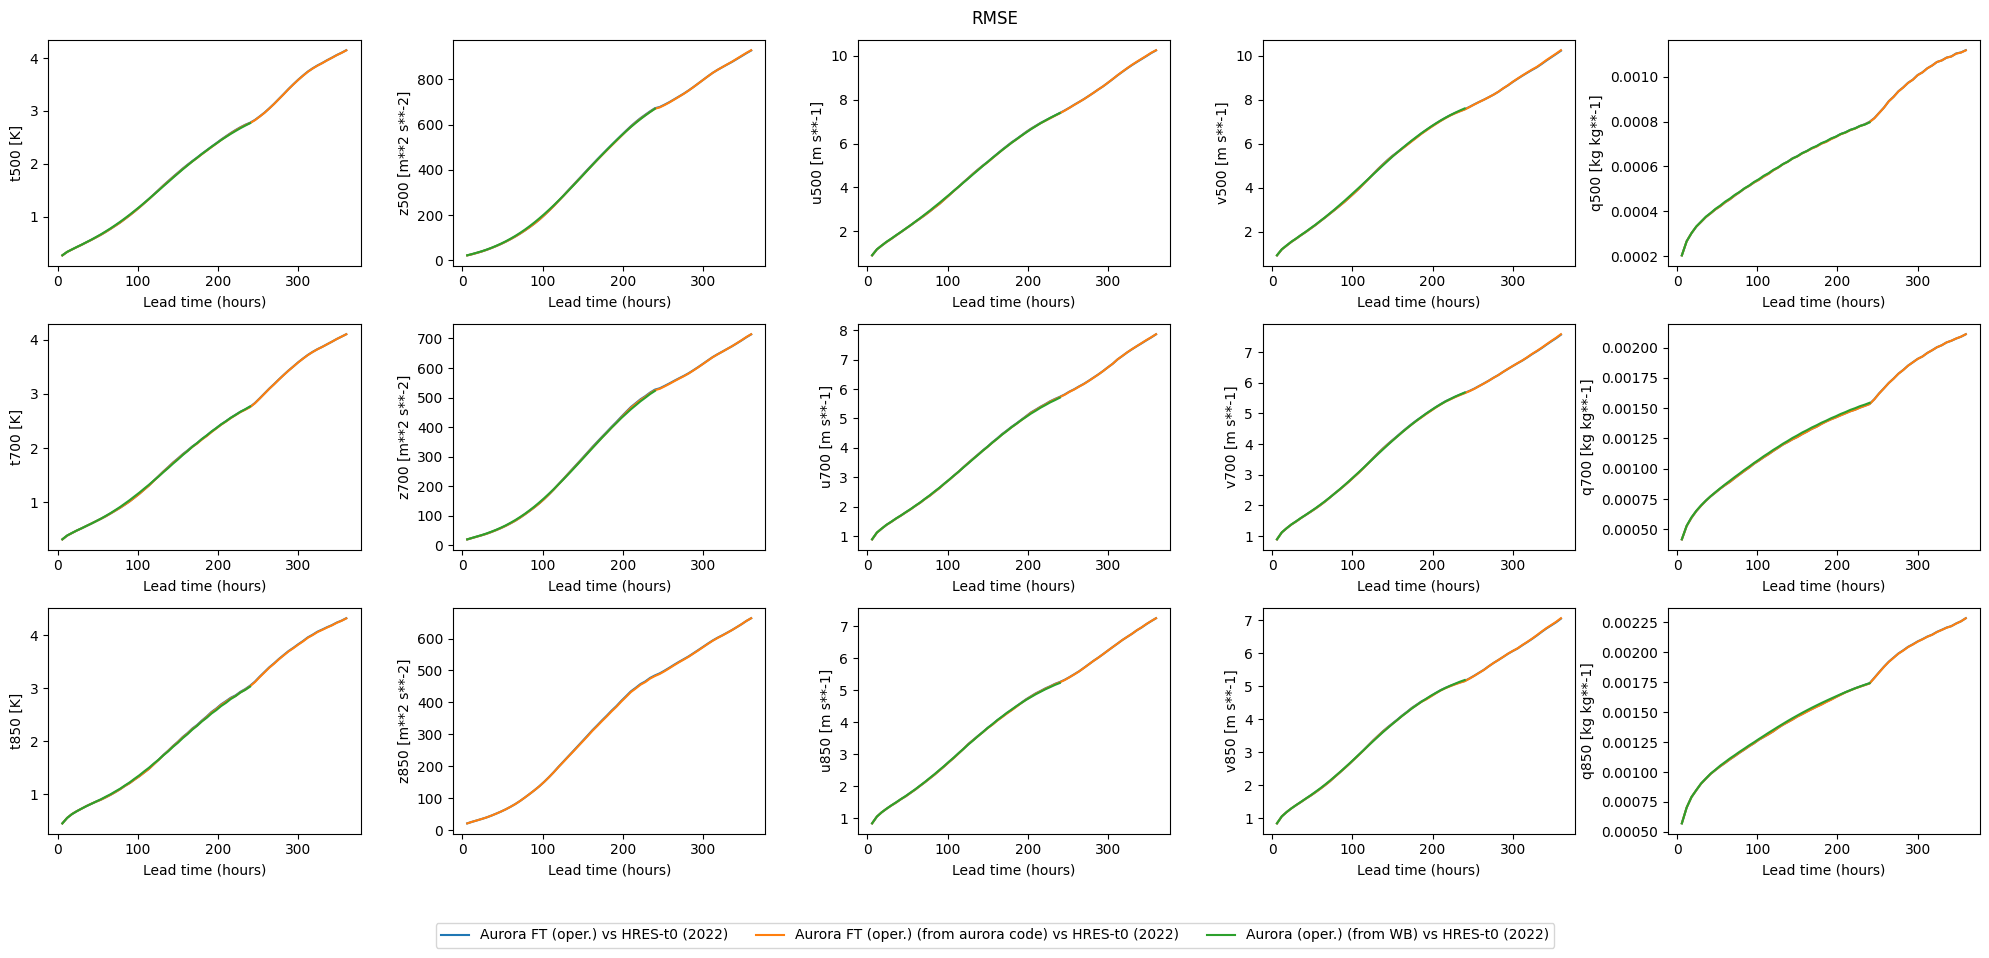

In [ ]:
keys = [
    # "aurora_pretrained_1440x721_2022",
    #'aurora_finetuned_no_lora_hres_init_1440x721_2022',
    'aurora_finetuned_hres_init_1440x721_2022', # run by me, Xaurora code
    'aurora_finetuned_from_aurora_hres_init_1440x721_2022', # run by me, Aurora code
    'aurora_hres_init_vs_hres_t0_2022' # official
]
metrics = ['rmse' for _ in keys]
datasets = adapt_datasets([
    load_anything(CONFIG[key]['metrics_path']) for key in keys
])
labels = [
    # "Aurora PT vs ERA5 (2022)",
    #"Aurora FT (no LoRA) vs ERA5 (2022)",
    "Aurora FT (oper.) vs HRES-t0 (2022)",
    "Aurora FT (oper.) (from aurora code) vs HRES-t0 (2022)",
    "Aurora (oper.) (from WB) vs HRES-t0 (2022)"
]
plot_metric(
    metrics=metrics,
    datasets=datasets,
    labels=labels,
    which_variables="surface",
    sel_kwargs={"region": "global"},
)
plot_metric(
    metrics=metrics,
    datasets=datasets,
    labels=labels,
    which_variables="atmospheric",
    sel_kwargs={"region": "global"},
)

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1271k  100 1271k    0     0  4834k      0 --:--:-- --:--:-- --:--:-- 4851k


/var/folders/l9/513m2x1n1xj1ss41yczgxvmr0000gn/T/ipykernel_4887/1833877850.py:14: FutureWarning: In a future version, xarray will not decode the variable 'lead_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  return xr.open_dataset(local_path)


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1271k  100 1271k    0     0  5239k      0 --:--:-- --:--:-- --:--:-- 5252k


/var/folders/l9/513m2x1n1xj1ss41yczgxvmr0000gn/T/ipykernel_4887/1833877850.py:14: FutureWarning: In a future version, xarray will not decode the variable 'lead_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  return xr.open_dataset(local_path)


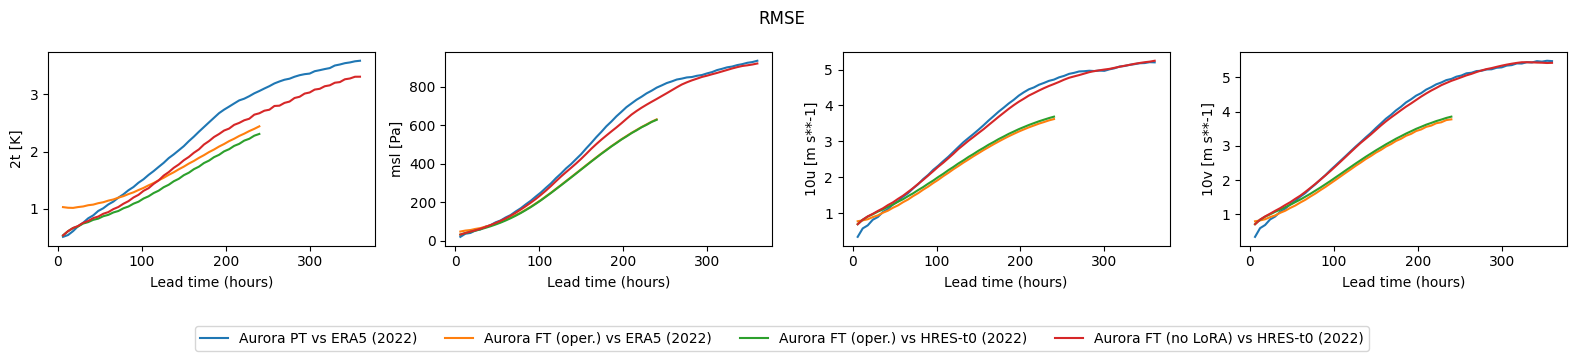

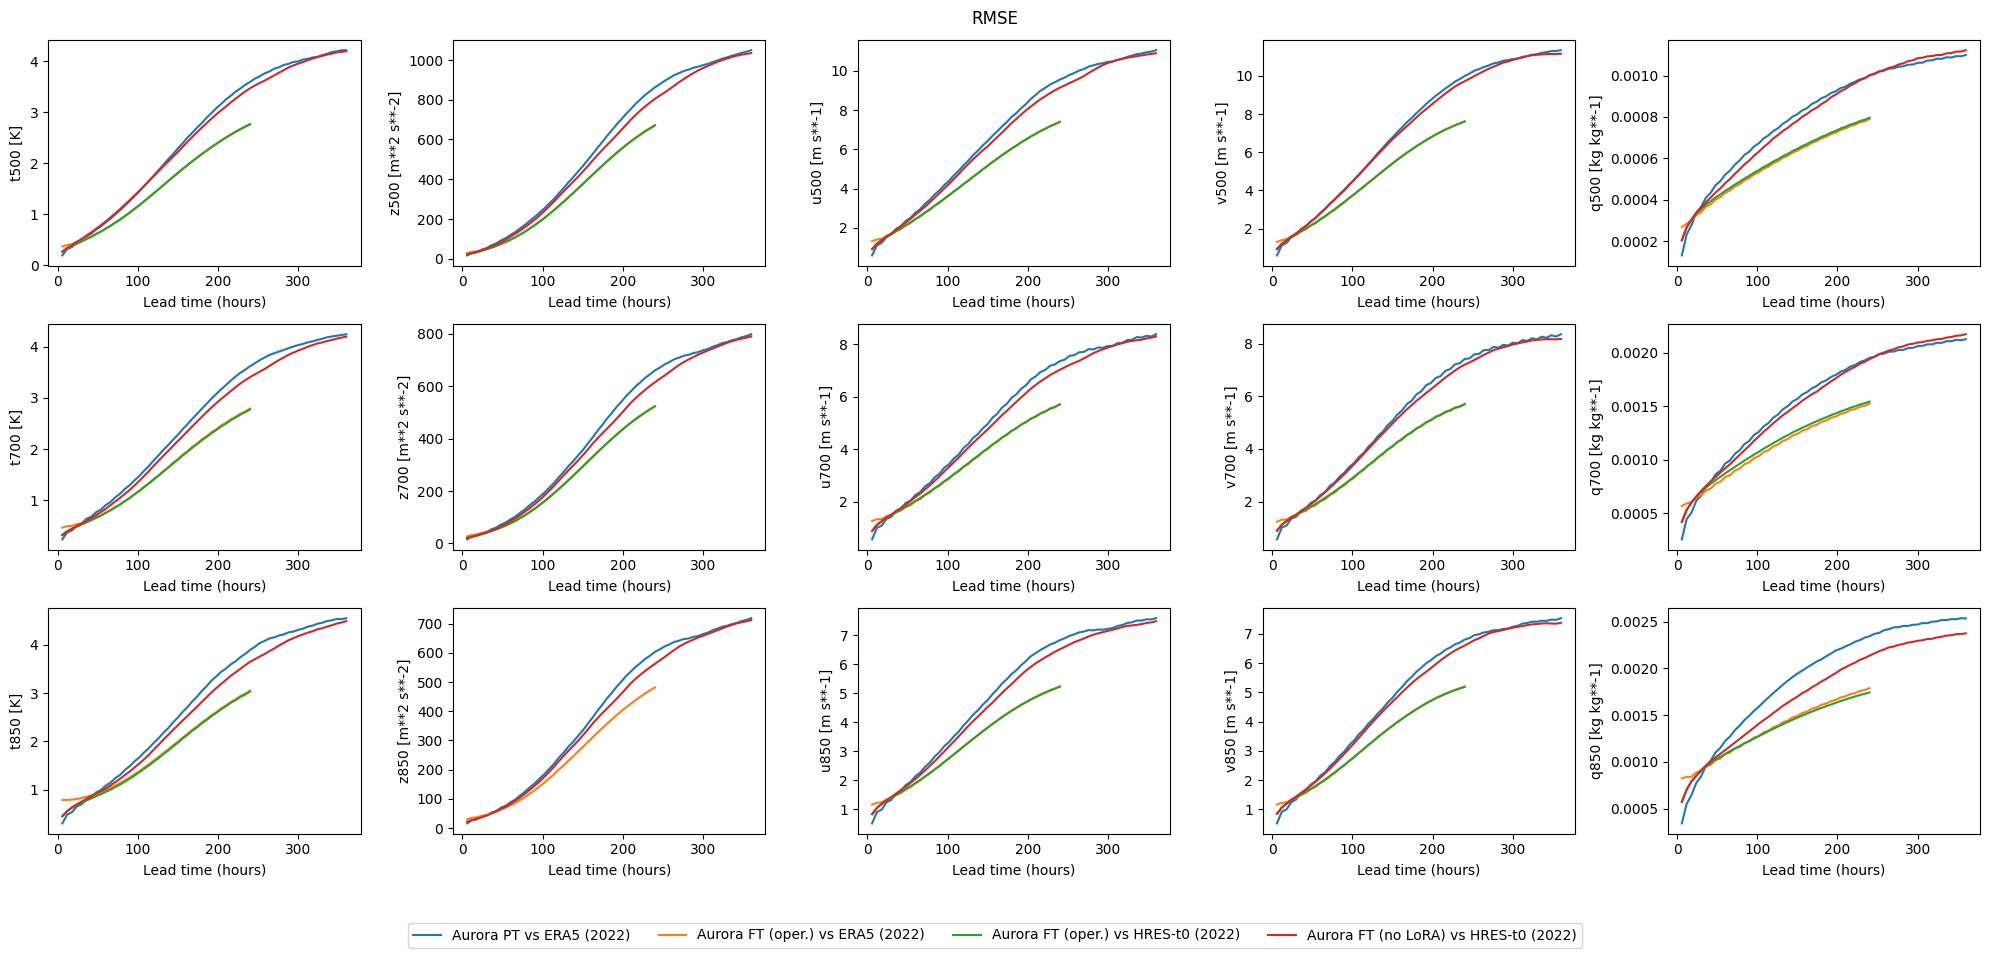

In [19]:
keys = [
    "aurora_pretrained_1440x721_2022",
    "aurora_vs_era5_2022", # official 
    'aurora_hres_init_vs_hres_t0_2022', # run by me, Xaurora code
    'aurora_finetuned_no_lora_hres_init_1440x721_2022'
]
metrics = ['rmse' for _ in keys]
datasets = adapt_datasets([
    load_anything(CONFIG[key]['metrics_path']) for key in keys
])
labels = [
    "Aurora PT vs ERA5 (2022)",
    "Aurora FT (oper.) vs ERA5 (2022)",
    "Aurora FT (oper.) vs HRES-t0 (2022)",
    "Aurora FT (no LoRA) vs HRES-t0 (2022)"
]
plot_metric(
    metrics=metrics,
    datasets=datasets,
    labels=labels,
    which_variables="surface",
    sel_kwargs={"region": "global"},
)
plot_metric(
    metrics=metrics,
    datasets=datasets,
    labels=labels,
    which_variables="atmospheric",
    sel_kwargs={"region": "global"},
)